# 📘 Notebook 5: Supervised Fine-Tuning (SFT)
## Building LLMs from Scratch Workshop

**Objective:** Fine-tune the pretrained GPT model on instruction-response pairs to follow instructions.

**What you'll learn:**
1. Creating instruction datasets (prompt → response format)
2. Formatting data for instruction tuning
3. **Loss masking** — training only on response tokens (not prompts)
4. Fine-tuning loop with evaluation
5. Comparing base model vs. SFT model outputs

**Key Insight:** SFT transforms a text-completion model into an instruction-following model.

---


## 1. Setup — Load Everything from Previous Notebooks

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math, time, json, re, copy
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [ ]:
# ============================================================
# Project Directory Setup
# ============================================================
# This cell ensures all paths point to the correct directories
# regardless of where you run the notebook from.
import os

# If running from notebooks/ folder
if os.path.basename(os.getcwd()) == 'notebooks':
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

# Create directories if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Results dir:  {RESULTS_DIR}")


In [2]:
# ============================================================
# Rebuild all components (same as Notebook 4)
# ============================================================
class BPETokenizer:
    def __init__(self, num_merges=100):
        self.num_merges = num_merges
        self.merges = {}
        self.vocab = {}
        self.inverse_vocab = {}
        self.special_tokens = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}
    
    def _get_word_freqs(self, text):
        words = re.findall(r'\S+', text.lower())
        word_freqs = Counter(words)
        return {tuple(list(w) + ['</w>']): f for w, f in word_freqs.items()}
    
    def _get_pair_counts(self, wf):
        pairs = Counter()
        for wt, f in wf.items():
            for i in range(len(wt)-1):
                pairs[(wt[i], wt[i+1])] += f
        return pairs
    
    def _merge_pair(self, wf, pair):
        m = pair[0]+pair[1]
        new_wf = {}
        for wt, f in wf.items():
            nt = []; i = 0
            while i < len(wt):
                if i < len(wt)-1 and wt[i]==pair[0] and wt[i+1]==pair[1]:
                    nt.append(m); i += 2
                else:
                    nt.append(wt[i]); i += 1
            new_wf[tuple(nt)] = f
        return new_wf
    
    def train(self, text):
        wf = self._get_word_freqs(text)
        ic = set(t for wt in wf for t in wt)
        for i in range(self.num_merges):
            pairs = self._get_pair_counts(wf)
            if not pairs: break
            bp, c = pairs.most_common(1)[0]
            if c < 2: break
            self.merges[bp] = bp[0]+bp[1]
            wf = self._merge_pair(wf, bp)
        self.vocab = dict(self.special_tokens)
        idx = len(self.special_tokens)
        for ch in sorted(ic):
            if ch not in self.vocab: self.vocab[ch] = idx; idx += 1
        for p, m in self.merges.items():
            if m not in self.vocab: self.vocab[m] = idx; idx += 1
        self.inverse_vocab = {v:k for k,v in self.vocab.items()}
    
    def _tokenize_word(self, word):
        tokens = list(word) + ['</w>']
        for pair, merged in self.merges.items():
            i = 0
            while i < len(tokens)-1:
                if tokens[i]==pair[0] and tokens[i+1]==pair[1]:
                    tokens = tokens[:i]+[merged]+tokens[i+2:]
                else: i += 1
        return tokens
    
    def encode(self, text):
        ids = []
        for w in re.findall(r'\S+', text.lower()):
            for t in self._tokenize_word(w):
                ids.append(self.vocab.get(t, self.vocab['<UNK>']))
        return ids
    
    def decode(self, ids):
        return ''.join(self.inverse_vocab.get(i,'?') for i in ids).replace('</w>',' ').strip()
    
    @property
    def vocab_size(self): return len(self.vocab)

# GPT Model components
class LayerNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.eps=eps; self.gamma=nn.Parameter(torch.ones(d)); self.beta=nn.Parameter(torch.zeros(d))
    def forward(self, x):
        m=x.mean(-1,keepdim=True); v=x.var(-1,keepdim=True,unbiased=False)
        return self.gamma*(x-m)/torch.sqrt(v+self.eps)+self.beta

class CausalMultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d=cfg['emb_dim']; self.nh=cfg['num_heads']; self.hd=d//self.nh
        self.qkv=nn.Linear(d,3*d,bias=False); self.out=nn.Linear(d,d,bias=False)
        self.ad=nn.Dropout(cfg['drop_rate']); self.rd=nn.Dropout(cfg['drop_rate'])
        mask=torch.triu(torch.ones(cfg['context_length'],cfg['context_length']),diagonal=1)
        self.register_buffer('mask',mask.bool())
    def forward(self, x):
        B,T,C=x.shape; Q,K,V=self.qkv(x).chunk(3,dim=-1)
        Q=Q.view(B,T,self.nh,self.hd).transpose(1,2)
        K=K.view(B,T,self.nh,self.hd).transpose(1,2)
        V=V.view(B,T,self.nh,self.hd).transpose(1,2)
        a=Q@K.transpose(-2,-1)/(self.hd**0.5)
        a.masked_fill_(self.mask[:T,:T].unsqueeze(0).unsqueeze(0),float('-inf'))
        a=self.ad(F.softmax(a,dim=-1))
        return self.rd(self.out((a@V).transpose(1,2).contiguous().view(B,T,C)))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(cfg['emb_dim'],cfg['emb_dim']*cfg.get('ff_mult',4)),
            nn.GELU(),nn.Linear(cfg['emb_dim']*cfg.get('ff_mult',4),cfg['emb_dim']),nn.Dropout(cfg['drop_rate']))
    def forward(self, x): return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1=LayerNorm(cfg['emb_dim']); self.attn=CausalMultiHeadAttention(cfg)
        self.ln2=LayerNorm(cfg['emb_dim']); self.ffn=FeedForward(cfg)
    def forward(self, x):
        x=x+self.attn(self.ln1(x)); x=x+self.ffn(self.ln2(x)); return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config=cfg
        self.tok_emb=nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
        self.pos_emb=nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.drop=nn.Dropout(cfg['drop_rate'])
        self.blocks=nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['num_layers'])])
        self.final_ln=LayerNorm(cfg['emb_dim'])
        self.lm_head=nn.Linear(cfg['emb_dim'],cfg['vocab_size'],bias=False)
        self.lm_head.weight=self.tok_emb.weight
        self.apply(self._init_w)
    def _init_w(self, m):
        if isinstance(m,nn.Linear):
            nn.init.normal_(m.weight,std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m,nn.Embedding): nn.init.normal_(m.weight,std=0.02)
    def forward(self, ids, targets=None):
        B,T=ids.shape
        x=self.drop(self.tok_emb(ids)+self.pos_emb(torch.arange(T,device=ids.device)))
        x=self.lm_head(self.final_ln(self.blocks(x)))
        loss=None
        if targets is not None: loss=F.cross_entropy(x.view(-1,x.size(-1)),targets.view(-1),reduction='none')
        return x, loss

print("All components loaded!")


All components loaded!


## 2. Creating the Instruction Dataset

For SFT, we need **(instruction, response)** pairs. We format them with special markers:

```
<BOS>### Instruction:
What is machine learning?
### Response:
Machine learning is a subset of AI that learns from data.
<EOS>
```

**Critical: Loss Masking** — We only compute loss on the **response** tokens, not the instruction tokens. This teaches the model to *generate* responses, not to *repeat* instructions.


In [3]:
# ============================================================
# Synthetic Instruction Dataset
# ============================================================
INSTRUCTION_DATA = [
    {
        "instruction": "What is machine learning?",
        "response": "Machine learning is a subset of artificial intelligence that enables systems to learn and improve from data without being explicitly programmed."
    },
    {
        "instruction": "Explain what a neural network is.",
        "response": "A neural network is a computing system inspired by biological neural networks. It consists of layers of interconnected nodes that process information and learn patterns from data."
    },
    {
        "instruction": "What is a transformer?",
        "response": "A transformer is a deep learning architecture that uses self-attention mechanisms to process sequential data. It was introduced in the paper Attention Is All You Need and is the foundation of modern language models."
    },
    {
        "instruction": "How does attention work?",
        "response": "Attention allows each element in a sequence to look at all other elements and compute relevance scores. It uses queries keys and values to determine which parts of the input are most important for each output position."
    },
    {
        "instruction": "What is tokenization?",
        "response": "Tokenization is the process of converting raw text into smaller units called tokens. These tokens are then mapped to numerical IDs that the model can process. Common methods include byte-pair encoding."
    },
    {
        "instruction": "Explain the difference between pretraining and fine-tuning.",
        "response": "Pretraining teaches a model general language understanding using large amounts of text data. Fine-tuning then adapts this pretrained model to specific tasks using smaller targeted datasets."
    },
    {
        "instruction": "What is RLHF?",
        "response": "RLHF stands for Reinforcement Learning from Human Feedback. It is a training method that uses human preferences to guide model behavior. A reward model is trained on human comparisons and then used to optimize the language model."
    },
    {
        "instruction": "What is the purpose of dropout?",
        "response": "Dropout is a regularization technique that randomly sets a fraction of neurons to zero during training. This prevents the model from relying too heavily on any single neuron and helps prevent overfitting."
    },
    {
        "instruction": "Explain gradient descent.",
        "response": "Gradient descent is an optimization algorithm that iteratively adjusts model parameters to minimize the loss function. It computes the gradient of the loss with respect to parameters and updates them in the opposite direction."
    },
    {
        "instruction": "What is cross-entropy loss?",
        "response": "Cross-entropy loss measures the difference between predicted probability distributions and actual labels. For language models it measures how well the model predicts the correct next token at each position."
    },
    {
        "instruction": "What is a learning rate?",
        "response": "The learning rate controls how much model parameters change during each optimization step. Too high causes instability and too low causes slow convergence. Scheduling the learning rate during training often improves results."
    },
    {
        "instruction": "Explain batch normalization vs layer normalization.",
        "response": "Batch normalization normalizes across the batch dimension while layer normalization normalizes across the feature dimension. Transformers use layer normalization because it works better with variable sequence lengths."
    },
    {
        "instruction": "What is perplexity?",
        "response": "Perplexity is a metric that measures how well a language model predicts text. It equals the exponential of the average cross-entropy loss. Lower perplexity indicates better prediction ability."
    },
    {
        "instruction": "What is transfer learning?",
        "response": "Transfer learning is a technique where a model trained on one task is reused as the starting point for a different task. In NLP pretraining on large text corpora and then fine-tuning on specific tasks is a common form of transfer learning."
    },
    {
        "instruction": "How does text generation work in language models?",
        "response": "Text generation works by repeatedly predicting the next token given previous tokens. The model outputs a probability distribution over the vocabulary and a token is selected using strategies like greedy decoding temperature sampling or top-k sampling."
    },
]

# Repeat dataset to have more training samples  
INSTRUCTION_DATA = INSTRUCTION_DATA * 4  # 60 samples
print(f"Total instruction-response pairs: {len(INSTRUCTION_DATA)}")
print(f"\nExample:")
print(f"  Instruction: {INSTRUCTION_DATA[0]['instruction']}")
print(f"  Response:    {INSTRUCTION_DATA[0]['response'][:100]}...")


Total instruction-response pairs: 60

Example:
  Instruction: What is machine learning?
  Response:    Machine learning is a subset of artificial intelligence that enables systems to learn and improve fr...


## 3. SFT Dataset with Loss Masking

**This is the key innovation of SFT:** We only compute loss on the **response tokens**.

```
Tokens:     [<BOS>] [###] [Inst] [:] [What] [is] [ML] [?] [###] [Resp] [:] [ML] [is] [...] [<EOS>]
Loss mask:  [  0  ] [ 0 ] [ 0  ] [0] [ 0  ] [ 0] [ 0] [0] [ 0 ] [  0 ] [0] [ 1] [ 1] [...] [  1 ]
```

We mask the instruction part so the model learns to **generate** responses, not memorize instructions.


In [4]:
class SFTDataset(Dataset):
    """
    Dataset for Supervised Fine-Tuning with loss masking.
    
    Formats each example as:
        <BOS> ### Instruction:\n{instruction}\n### Response:\n{response} <EOS>
    
    Loss is computed ONLY on response tokens + EOS.
    """
    
    def __init__(self, data, tokenizer, context_length=64):
        self.samples = []
        self.context_length = context_length
        
        # Instruction/Response markers
        inst_marker = "### instruction:"
        resp_marker = "### response:"
        
        skipped = 0
        for item in data:
            # Format the prompt
            formatted = f"{inst_marker} {item['instruction']} {resp_marker} {item['response']}"
            
            # Tokenize
            token_ids = tokenizer.encode(formatted)
            
            # Find where the response starts
            resp_tokens = tokenizer.encode(resp_marker)
            
            # Find response start position in the full sequence
            resp_start = None
            for i in range(len(token_ids) - len(resp_tokens) + 1):
                if token_ids[i:i+len(resp_tokens)] == resp_tokens:
                    resp_start = i + len(resp_tokens)  # After the marker
                    break
            
            if resp_start is None:
                resp_start = len(token_ids) // 2  # Fallback
            
            # Pad or truncate to context_length
            if len(token_ids) > context_length:
                token_ids = token_ids[:context_length]
                if resp_start > context_length:
                    skipped += 1
                    continue
            
            # Create input and target
            # Input: all tokens except last
            # Target: all tokens shifted by 1
            if len(token_ids) < 3:
                skipped += 1
                continue
            
            # Pad to context_length
            pad_id = tokenizer.vocab.get('<PAD>', 0)
            padded_len = min(len(token_ids), context_length)
            
            input_ids = token_ids[:padded_len-1]
            target_ids = token_ids[1:padded_len]
            
            # Pad both to context_length - 1
            target_len = context_length - 1
            while len(input_ids) < target_len:
                input_ids.append(pad_id)
                target_ids.append(pad_id)
            
            input_ids = input_ids[:target_len]
            target_ids = target_ids[:target_len]
            
            # Create loss mask: 1 for response tokens, 0 for instruction/padding
            loss_mask = [0.0] * len(target_ids)
            # The response starts at resp_start in the original sequence
            # In shifted target, response tokens start at resp_start - 1
            mask_start = max(0, resp_start - 1)
            for i in range(mask_start, min(padded_len - 1, len(loss_mask))):
                loss_mask[i] = 1.0
            
            self.samples.append({
                'input_ids': torch.tensor(input_ids, dtype=torch.long),
                'target_ids': torch.tensor(target_ids, dtype=torch.long),
                'loss_mask': torch.tensor(loss_mask, dtype=torch.float),
            })
        
        print(f"Created SFT dataset: {len(self.samples)} samples (skipped {skipped})")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        return s['input_ids'], s['target_ids'], s['loss_mask']

# First, train a tokenizer on instruction data
all_text = " ".join(
    f"### instruction: {d['instruction']} ### response: {d['response']}" 
    for d in INSTRUCTION_DATA
)

# Include our original corpus for better tokenization
CORPUS = """The quick brown fox jumps over the lazy dog.
Machine learning is a subset of artificial intelligence.
Neural networks learn representations from data automatically.
Transformers revolutionized natural language processing in 2017.
Attention is all you need was the groundbreaking paper by Google.
Large language models can generate human-like text fluently.
GPT stands for Generative Pre-trained Transformer architecture.
Training a language model requires massive amounts of text data.
Tokenization converts raw text into numerical sequences for models.
""" * 5

full_text = CORPUS + " " + all_text

tokenizer = BPETokenizer(num_merges=250)
tokenizer.train(full_text)
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")

# Create dataset
CONTEXT_LENGTH = 64
sft_dataset = SFTDataset(INSTRUCTION_DATA, tokenizer, context_length=CONTEXT_LENGTH)

# Inspect a sample
inp, tgt, mask = sft_dataset[0]
print(f"\nSample shapes:")
print(f"  input_ids:  {inp.shape}")
print(f"  target_ids: {tgt.shape}")
print(f"  loss_mask:  {mask.shape}")
print(f"  # response tokens (mask=1): {mask.sum().item():.0f}")
print(f"  # masked tokens (mask=0):   {(mask == 0).sum().item():.0f}")


Tokenizer vocab size: 290
Created SFT dataset: 60 samples (skipped 0)

Sample shapes:
  input_ids:  torch.Size([63])
  target_ids: torch.Size([63])
  loss_mask:  torch.Size([63])
  # response tokens (mask=1): 54
  # masked tokens (mask=0):   9


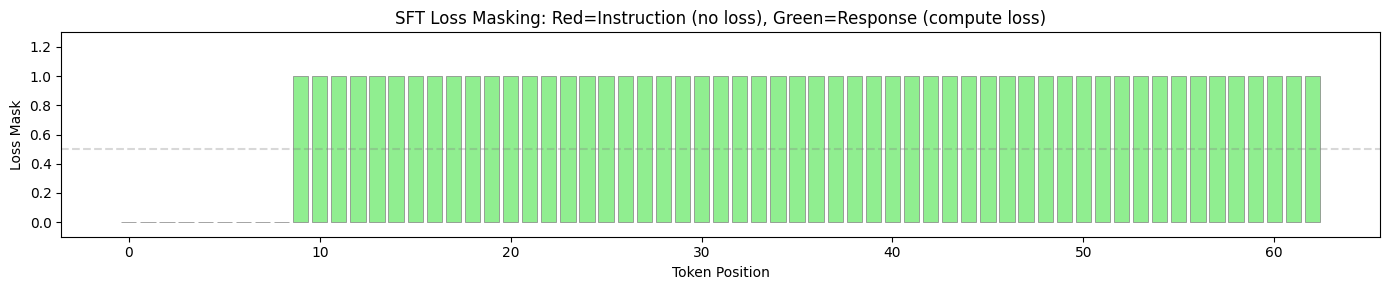

Green = model learns to generate these tokens
Red = model doesn't learn from these (instruction tokens)


In [6]:
# Visualize loss masking
sample_idx = 0
inp, tgt, mask = sft_dataset[sample_idx]

fig, ax = plt.subplots(figsize=(14, 3))
colors = ['lightcoral' if m == 0 else 'lightgreen' for m in mask.tolist()]
ax.bar(range(len(mask)), mask.tolist(), color=colors, edgecolor='gray', linewidth=0.5)
ax.set_xlabel('Token Position')
ax.set_ylabel('Loss Mask')
ax.set_title('SFT Loss Masking: Red=Instruction (no loss), Green=Response (compute loss)')
ax.set_ylim(-0.1, 1.3)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\loss_masking.png', dpi=100)
plt.show()
print("Green = model learns to generate these tokens")
print("Red = model doesn't learn from these (instruction tokens)")


## 4. SFT Training Loop

Key differences from pretraining:
1. **Loss masking** — only compute loss on response tokens
2. **Lower learning rate** — we don't want to destroy pretrained knowledge
3. **Fewer epochs** — fine-tuning is quick


In [8]:
# ============================================================
# Initialize Model (pretrained or fresh)
# ============================================================
GPT_CONFIG = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": CONTEXT_LENGTH,
    "emb_dim": 128,
    "num_heads": 4,
    "num_layers": 4,
    "drop_rate": 0.1,
    "ff_mult": 4,
}

# Initialize fresh model (in a real scenario, you'd load from Notebook 4's checkpoint)
model = GPTModel(GPT_CONFIG).to(device)

# Try to load pretrained weights if available
try:
    ckpt = torch.load(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\models\\gpt_pretrained_final.pt', map_location=device, weights_only=False)
    if ckpt['config']['vocab_size'] == GPT_CONFIG['vocab_size']:
        model.load_state_dict(ckpt['model_state_dict'])
        print("Loaded pretrained weights!")
    else:
        print("Vocab size mismatch — starting from scratch (this is fine for the workshop)")
except FileNotFoundError:
    print("No pretrained model found — training SFT from randomly initialized model")
    print("(In practice, you'd always start from a pretrained checkpoint)")

# Save a copy of the base model for comparison later
base_model = GPTModel(GPT_CONFIG).to(device)
base_model.load_state_dict(model.state_dict())
base_model.eval()

params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {params:,}")


Vocab size mismatch — starting from scratch (this is fine for the workshop)

Model parameters: 836,608


In [9]:
# ============================================================
# SFT Training Configuration
# ============================================================
BATCH_SIZE = 4
NUM_EPOCHS = 20
SFT_LR = 1e-4         # Lower LR than pretraining
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0

# Split into train/val
n_val = max(2, len(sft_dataset) // 10)
n_train = len(sft_dataset) - n_val
train_data, val_data = torch.utils.data.random_split(sft_dataset, [n_train, n_val])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Train batches: {len(train_loader)}")

optimizer = torch.optim.AdamW(model.parameters(), lr=SFT_LR, weight_decay=WEIGHT_DECAY)


Train samples: 54
Val samples:   6
Train batches: 13


In [10]:
# ============================================================
# SFT TRAINING LOOP (with loss masking)
# ============================================================

@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_new=40, temp=0.7, top_k=15, device='cpu'):
    model.eval()
    ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
    ctx = model.config['context_length']
    for _ in range(max_new):
        idx = ids[:, -ctx:]
        logits, _ = model(idx)
        logits = logits[:, -1, :] / max(temp, 1e-8)
        if top_k:
            tv, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < tv[:, -1:]] = float('-inf')
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1) if temp > 0 else torch.argmax(probs, -1, keepdim=True)
        ids = torch.cat([ids, nxt], 1)
    return tokenizer.decode(ids[0].tolist())

print("=" * 60)
print("STARTING SFT TRAINING")
print("=" * 60)

train_losses = []
val_losses = []
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_tokens = 0
    
    for input_ids, target_ids, loss_mask in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        loss_mask = loss_mask.to(device)
        
        # Forward pass — get per-token losses
        logits, per_token_loss = model(input_ids, target_ids)
        # per_token_loss shape: [batch * seq_len]
        
        # Reshape loss mask to match
        flat_mask = loss_mask.view(-1)
        
        # Apply loss mask: only compute loss on response tokens
        masked_loss = per_token_loss * flat_mask
        
        # Average over masked tokens (avoid division by zero)
        num_response_tokens = flat_mask.sum()
        if num_response_tokens > 0:
            loss = masked_loss.sum() / num_response_tokens
        else:
            loss = masked_loss.sum()  # Fallback
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        train_losses.append(loss.item())
        epoch_loss += loss.item()
        epoch_tokens += num_response_tokens.item()
    
    # Validation
    model.eval()
    val_loss_total = 0
    val_tokens = 0
    with torch.no_grad():
        for input_ids, target_ids, loss_mask in val_loader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            loss_mask = loss_mask.to(device)
            _, ptl = model(input_ids, target_ids)
            fm = loss_mask.view(-1)
            n = fm.sum()
            if n > 0:
                val_loss_total += (ptl * fm).sum().item() / n.item()
            val_tokens += 1
    
    avg_train = epoch_loss / max(len(train_loader), 1)
    avg_val = val_loss_total / max(val_tokens, 1)
    val_losses.append(avg_val)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | Time: {elapsed:.0f}s")
    
    # Generate a sample every 5 epochs
    if (epoch + 1) % 5 == 0:
        sample = generate_text(model, tokenizer, "### instruction: what is machine learning? ### response:",
                              max_new=30, device=device)
        print(f"  Sample: {sample[:120]}...")

print(f"\nSFT training complete! Time: {time.time()-start_time:.0f}s")


STARTING SFT TRAINING
Epoch  1/20 | Train Loss: 5.5636 | Val Loss: 5.4508 | Time: 1s
Epoch  2/20 | Train Loss: 5.3438 | Val Loss: 5.2523 | Time: 1s
Epoch  3/20 | Train Loss: 5.1739 | Val Loss: 5.1298 | Time: 2s
Epoch  4/20 | Train Loss: 5.0179 | Val Loss: 4.9941 | Time: 2s
Epoch  5/20 | Train Loss: 4.8797 | Val Loss: 4.8360 | Time: 3s
  Sample: ### instruction: what is machine learning? ### response: w w of liquis a the seiinto ibgormea data. it eel### elus fa er...
Epoch  6/20 | Train Loss: 4.7507 | Val Loss: 4.7372 | Time: 4s
Epoch  7/20 | Train Loss: 4.6396 | Val Loss: 4.6225 | Time: 4s
Epoch  8/20 | Train Loss: 4.5409 | Val Loss: 4.5499 | Time: 5s
Epoch  9/20 | Train Loss: 4.4474 | Val Loss: 4.4494 | Time: 5s
Epoch 10/20 | Train Loss: 4.3601 | Val Loss: 4.3801 | Time: 6s
  Sample: ### instruction: what is machine learning? ### response: a a the is a pleleit is a reiintrelligininit is neural networks...
Epoch 11/20 | Train Loss: 4.2766 | Val Loss: 4.2900 | Time: 6s
Epoch 12/20 | Tra

## 5. Comparing Base Model vs. SFT Model

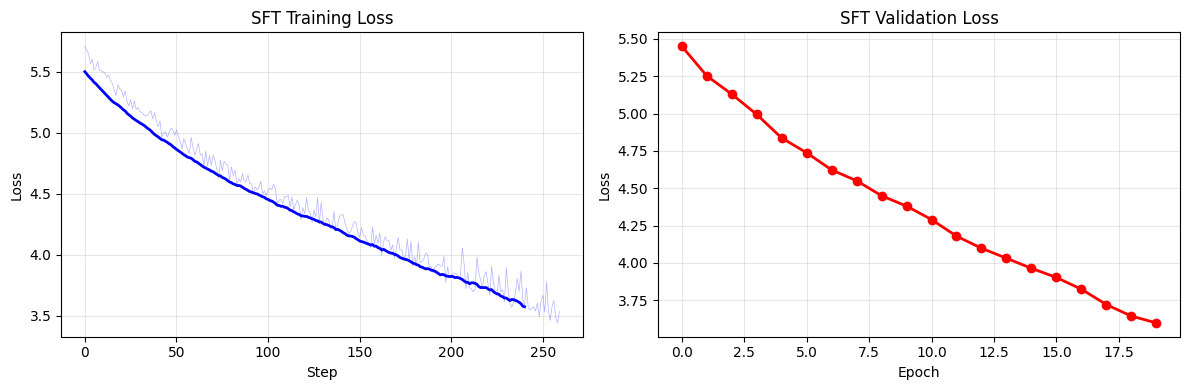

In [11]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, alpha=0.3, color='blue', linewidth=0.5)
w = min(20, len(train_losses)//3)
if w > 1:
    sm = np.convolve(train_losses, np.ones(w)/w, mode='valid')
    ax1.plot(sm, color='blue', linewidth=2)
ax1.set_title('SFT Training Loss')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_losses, 'ro-', linewidth=2)
ax2.set_title('SFT Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\sft_training.png', dpi=100)
plt.show()


In [12]:
# ============================================================
# Compare Base vs SFT Model
# ============================================================
test_prompts = [
    "### instruction: what is a neural network? ### response:",
    "### instruction: explain attention mechanism. ### response:",
    "### instruction: what is tokenization? ### response:",
    "### instruction: how does gradient descent work? ### response:",
]

print("=" * 70)
print("BASE MODEL vs SFT MODEL COMPARISON")
print("=" * 70)

for prompt in test_prompts:
    short_prompt = prompt.split("### response:")[0].replace("### instruction:", "Q:").strip()
    print(f"\n{'─' * 60}")
    print(f"Prompt: {short_prompt}")
    print(f"{'─' * 60}")
    
    # Base model
    base_out = generate_text(base_model, tokenizer, prompt, max_new=30, temp=0.7, device=device)
    response_part = base_out.split("### response:")[-1].strip() if "### response:" in base_out else base_out
    print(f"  Base:  {response_part[:100]}")
    
    # SFT model
    sft_out = generate_text(model, tokenizer, prompt, max_new=30, temp=0.7, device=device)
    response_part = sft_out.split("### response:")[-1].strip() if "### response:" in sft_out else sft_out
    print(f"  SFT:   {response_part[:100]}")

print(f"\n{'=' * 70}")
print("Note: With small model and data, differences may be subtle.")
print("With larger models and more data, SFT produces dramatically better instruction following.")


BASE MODEL vs SFT MODEL COMPARISON

────────────────────────────────────────────────────────────
Prompt: Q: what is a neural network?
────────────────────────────────────────────────────────────
  Base:  fine-tunulexplainureexplainall lsequneurlihuman neurlearnneurted ted ted ento opformmodasdurfine-tun
  SFT:   a a rearer eque is a model predicchirepts model caminls. smalof intof th

────────────────────────────────────────────────────────────
Prompt: Q: explain attention mechanism.
────────────────────────────────────────────────────────────
  Base:  ing ing responoucencneurumdifferlosneurexplainexplainworworall iworkneurneurlik taskine ineurlt fink
  SFT:   for a model of is a model model inforcadeate that noup learning model parais a proes a

────────────────────────────────────────────────────────────
Prompt: Q: what is tokenization?
────────────────────────────────────────────────────────────
  Base:  ting les t ing l l in learnounthen within larumdifwithwithsequsequeach urleart 

## 6. Save SFT Model for RLHF (Notebook 6)

In [13]:
# Save SFT model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': GPT_CONFIG,
    'tokenizer_vocab': tokenizer.vocab,
    'tokenizer_merges': {f"{k[0]}|||{k[1]}": v for k, v in tokenizer.merges.items()},
    'tokenizer_special_tokens': tokenizer.special_tokens,
    'tokenizer_num_merges': tokenizer.num_merges,
}, 'gpt_sft_model.pt')
print("SFT model saved to gpt_sft_model.pt")
print("Ready for RLHF in Notebook 6!")


SFT model saved to gpt_sft_model.pt
Ready for RLHF in Notebook 6!


## 7. Exercises & Summary

### Exercise 1: More Instructions
Add 20+ more instruction-response pairs. How does quality improve?

### Exercise 2: Mask Ablation
Train without loss masking (loss on all tokens). Compare results.

### Exercise 3: LoRA-style Fine-tuning
Implement a simple version where you only train specific layers (freeze others).

---

## 🎯 Interview Questions

1. **Why mask the instruction tokens during SFT?** — Without masking, the model wastes capacity learning to predict instruction text instead of focusing on generating good responses.

2. **Why use a lower learning rate for SFT vs pretraining?** — Too high a LR can destroy the general knowledge learned during pretraining. SFT aims for targeted adaptation.

3. **What's catastrophic forgetting?** — When fine-tuning overrides useful pretrained knowledge. Mitigated by lower LR, fewer epochs, and sometimes replaying pretraining data.

4. **How much data is needed for SFT?** — Surprisingly little. Studies show 1K-10K high-quality examples can dramatically improve instruction following.

---

## ✅ Summary

1. ✅ Created instruction-response dataset
2. ✅ Implemented loss masking for SFT
3. ✅ Trained SFT model with proper hyperparameters
4. ✅ Compared base vs SFT model outputs
5. ✅ Saved SFT model for RLHF

**Next: Notebook 6 — RLHF Implementation →**
